# DAI Mission — Proposal Template
**Data & AI in Economics | TU Dortmund**

This notebook is your team's mission proposal. Fill in every section before submission. Once approved, you will extend this same notebook into your final deliverable.

> **Team size:** 2–3 students  
> **Deliverable:** This Jupyter Notebook (proposal → final submission in one file)


## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead |Bekzod Amonov| |
| Member |Mariia Hrechyn | |
| Member |Lutz Weiland| | |


## 2. Mission Title & Research Question

**Title:** *Learning Signals or Optimizing Decisions? Cost-Sensitive Stock Trend Classification from Financial Fundamentals*

**Research question:**  
*When predicting buy, hold, and sell labels from S&P 500 fundamental financial indicators, do ensemble models improve performance because they learn stronger class-specific information from accounting variables, or because cost-sensitive decision rules better exploit uncertainty around the ambiguous hold class under the evaluation loss?*

**Why it matters:**  
*This mission examines the distinction between statistical prediction and economically meaningful decision-making in financial machine learning. In stock trend classification, a model with higher accuracy is not necessarily better if its mistakes imply costly trading actions. The FedCSIS 2024 challenge is useful for studying this problem because it combines weak public fundamental signals, an imbalanced three-class target, and an error-cost matrix where different mistakes have different economic severity. The project therefore asks whether improved leaderboard performance reflects genuine predictive structure in financial statement indicators or mainly better conversion of uncertain class probabilities into cautious trading decisions. This matters for investment screening because a deployable model should not only classify stocks, but also understand when the evidence is too weak for an aggressive buy or sell signal.*


## 3. Data

**Source(s):**  
*Name each dataset, its provider, URL or access method, and licence/terms of use.*

**Unit of observation:** *What does one row represent?*

**Key variables:**

| Variable | Type | Role (feature / target / instrument / ...) | Description |
|----------|------|---------------------------------------------|-------------|
| | | | |

**Potential data quality issues:**  
*Missing values, selection bias, measurement error — flag anything you already know about.*


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
test_data = pd.read_csv('test_data_no_target.csv', delimiter=';')
train_data = pd.read_csv('training_data.csv', delimiter=';')

train_data = train_data.astype(str)
train_data.iloc[:,1:] = train_data.loc[:,'I1':'Perform'].applymap(lambda s: s.replace(",",".")).astype(float)

column_dict_df = pd.read_csv('column_names_dictionary.csv', delimiter=';')
column_dict = dict(zip(column_dict_df['CODE'], column_dict_df['INDICATOR NAME']))
column_dict['Perform'] = 'Perform'  
column_dict['Class'] = 'Class' 

train_df = train_data.rename(columns=column_dict)
train_df.head()

C:\Users\B01511\AppData\Local\Temp\ipykernel_48364\3809510512.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_data.iloc[:,1:] = train_data.loc[:,'I1':'Perform'].applymap(lambda s: s.replace(",",".")).astype(float)


,Industry sector,"Return on Average Total Assets - %, TTM","Return on Average Common Equity - %, TTM","EBITDA Percentage of Common Equity, TTM","EBITDA Percentage of Total Fixed Assets - Net, TTM",Excess Cash Margin - %,"Free Cash Flow Percentage of Total Revenue, TTM","Cash Flow from Operations Pct of Total Revenue, TTM","Cash Flow from Operations Pct of Common Equity, TTM","Cash Flow from Operations to Total Assets, TTM",...,1-year Absolute Change of Working Capital to Total Assets,1-year Absolute Change of Cash Ratio,1-year Absolute Change of Net Debt to Total Equity,1-year Absolute Change of Total Liabilities Percentage of Total Assets,1-year Absolute Change of Long Term Debt Percentage of Total Assets,1-year Absolute Change of Book Value Percentage of Market Capitalization,1-year Absolute Change of Cash Flow from Operations Pct of Capital Expenditures,"1-year Absolute Change of Price to Cash Flow from Operations per Share, TTM",Class,Perform
0,G9,0.136495,-0.028429,-0.037772,-0.232459,-0.016222,-0.187506,-0.322545,-0.043743,0.125389,...,0.102563,0.188481,-0.016027,-0.135451,-0.189667,0.250967,0.022171,-0.004265,-1.0,-0.033764
1,G5,-0.714522,-0.042137,-0.052968,-0.796862,-0.018394,0.070102,-0.076321,-0.063864,-1.045521,...,-0.016375,0.020727,-0.006525,-0.01879,-0.098543,0.317744,-0.180502,-0.009215,1.0,0.127771
2,G10,0.104791,-0.038188,-0.053191,0.620233,0.148587,0.489875,0.319274,-0.060246,0.053174,...,0.272937,0.774169,-0.007144,0.123954,0.0,-0.110103,0.186669,-0.03072,1.0,0.1835
3,G2,-0.532847,-0.006582,-0.023377,1.306702,-0.068909,0.048024,-0.119481,-0.021057,-1.012916,...,0.004938,0.018494,-0.00335,-0.029214,0.045747,-0.076884,-0.037859,-0.012046,-1.0,-0.035668
4,G3,-0.200815,-0.016334,-0.036754,-0.886675,0.484495,-1.148744,0.152517,-0.04358,-0.935537,...,-0.014812,-0.324584,-0.019002,-0.379323,-0.046024,0.282145,0.011008,0.010496,1.0,0.235055


### Missing Values Analysis

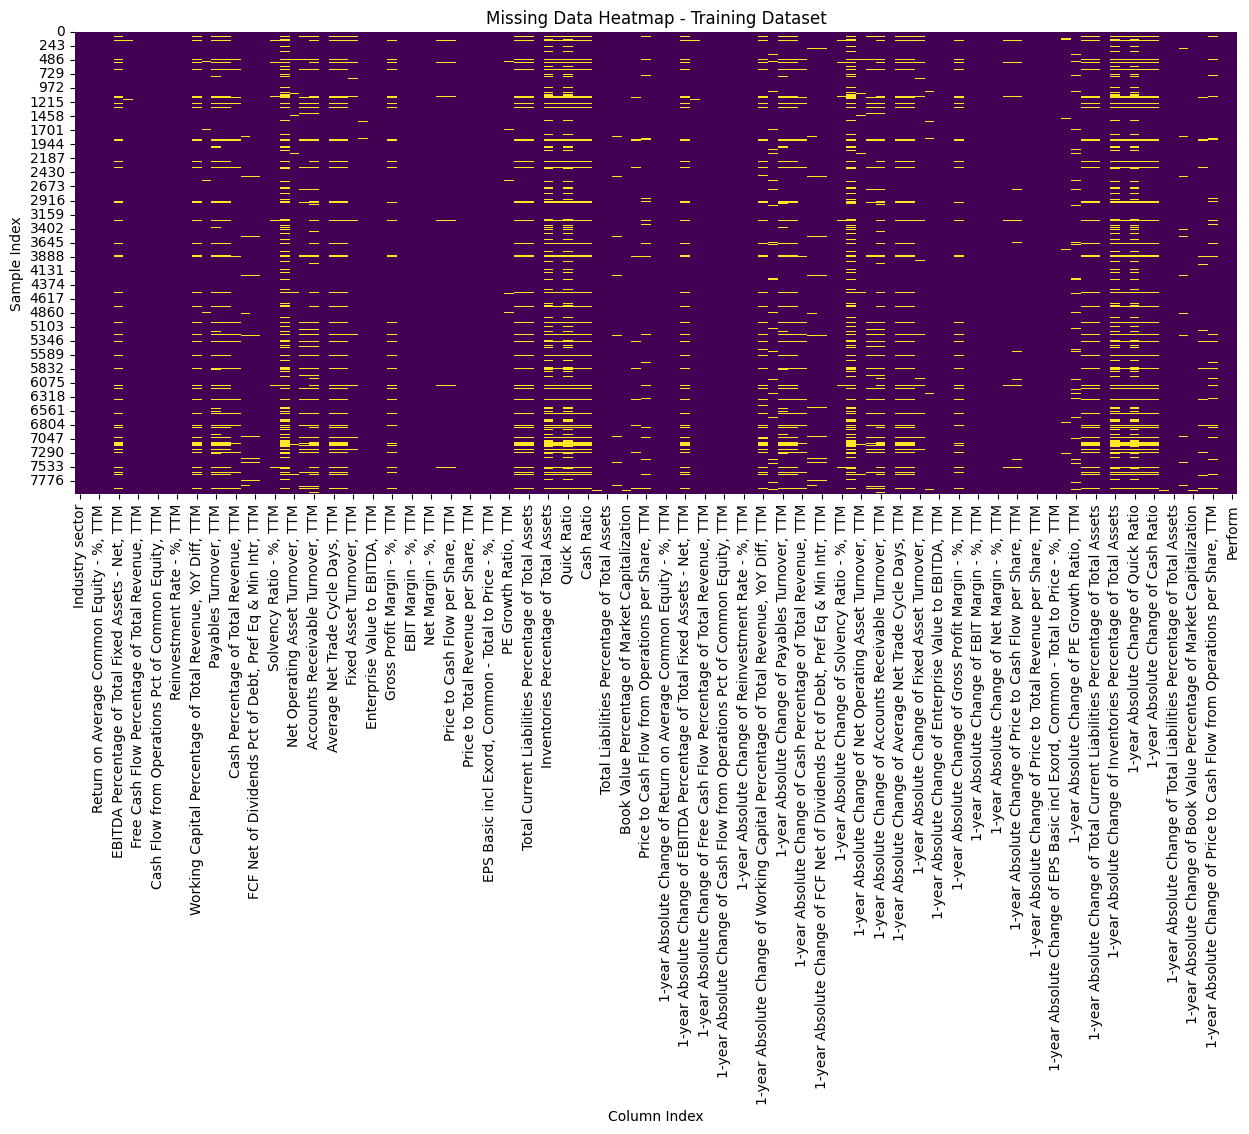

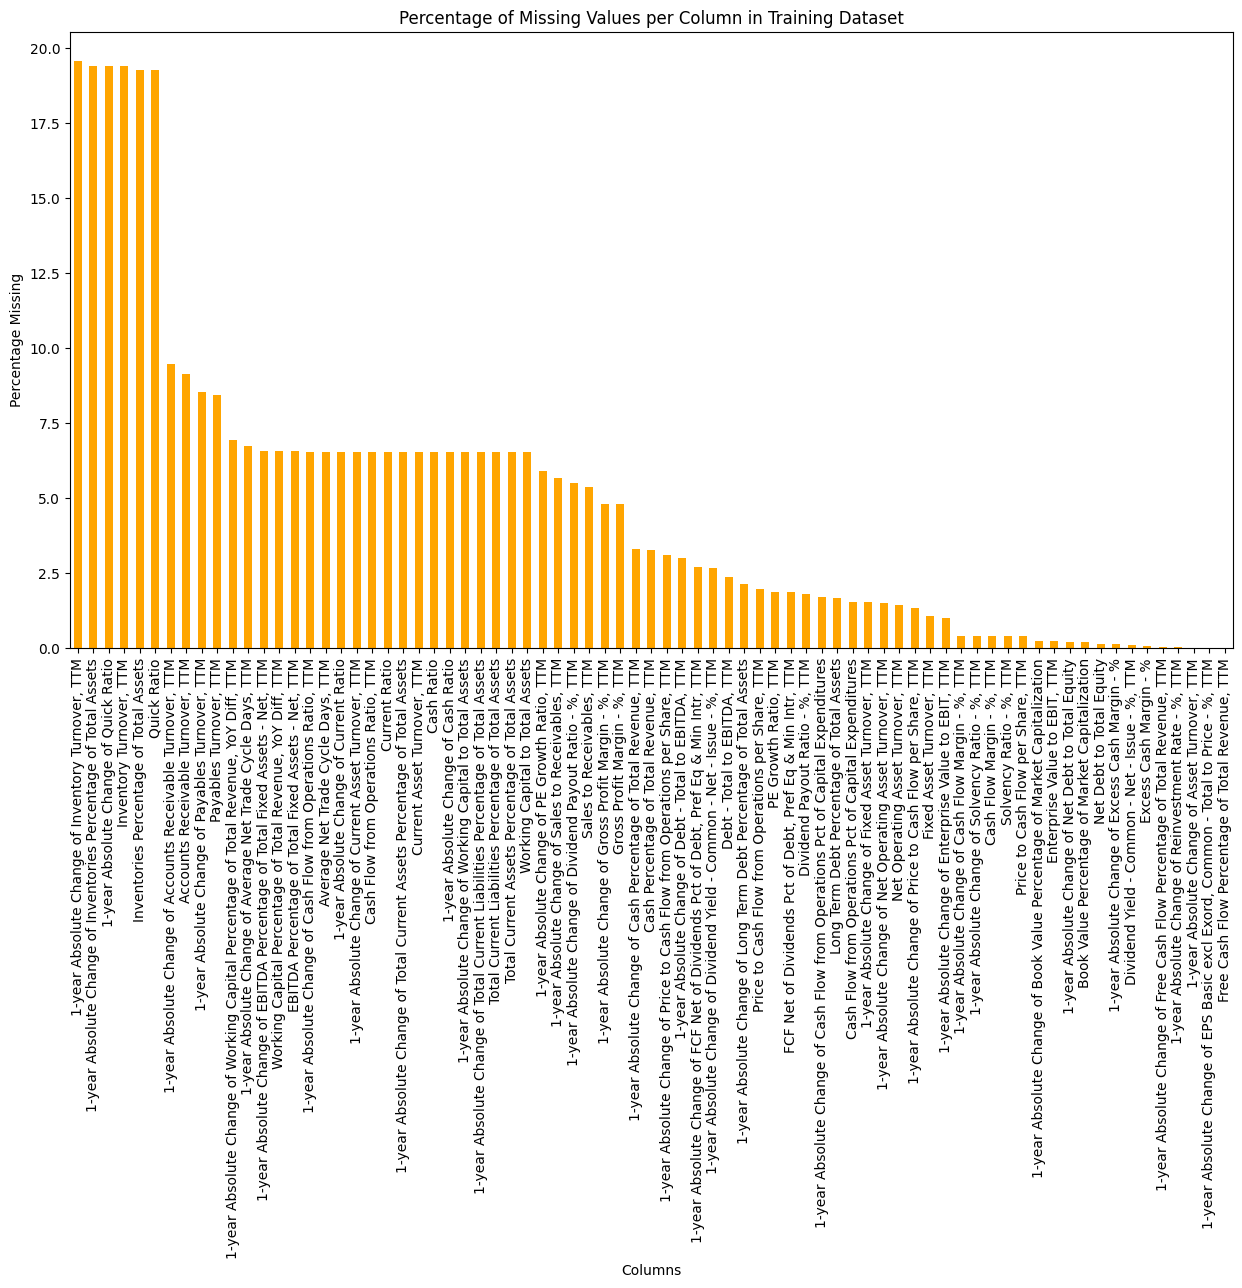

,Missing Values Training,Percentage Missing Training,Missing Values Test,Percentage Missing Test
"1-year Absolute Change of Inventory Turnover, TTM",1564.0,19.55,NaN,NaN
1-year Absolute Change of Inventories Percentage of Total Assets,1553.0,19.41,NaN,NaN
1-year Absolute Change of Quick Ratio,1553.0,19.41,NaN,NaN
"Inventory Turnover, TTM",1553.0,19.41,NaN,NaN
Inventories Percentage of Total Assets,1540.0,19.25,NaN,NaN
Quick Ratio,1540.0,19.25,NaN,NaN
"1-year Absolute Change of Accounts Receivable Turnover, TTM",757.0,9.46,NaN,NaN
"Accounts Receivable Turnover, TTM",730.0,9.12,NaN,NaN
"1-year Absolute Change of Payables Turnover, TTM",682.0,8.52,NaN,NaN
"Payables Turnover, TTM",675.0,8.44,NaN,NaN


In [ ]:
missing_values_train = train_df.isnull().sum()
percent_missing_train = (train_df.isnull().sum() / len(train_df) * 100).round(2)
missing_values_test = test_data.isnull().sum()
percent_missing_test = (test_data.isnull().sum() / len(test_data) * 100).round(2)

missing_data_comparison = pd.DataFrame({
    'Missing Values Training': missing_values_train,
    'Percentage Missing Training': percent_missing_train,
    'Missing Values Test': missing_values_test,
    'Percentage Missing Test': percent_missing_test})

missing_data_comparison[missing_data_comparison['Missing Values Training'] > 0].sort_values(by='Percentage Missing Training', ascending=False)

# missing values in training dataset
plt.figure(figsize=(15, 6))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap - Training Dataset')
plt.xlabel('Column Index')
plt.ylabel('Sample Index')
plt.show()

# percentage of missing values in the training dataset
missing_percent_train = missing_data_comparison[missing_data_comparison['Percentage Missing Training'] > 0]['Percentage Missing Training'].sort_values(ascending=False)
plt.figure(figsize=(15, 8))
missing_percent_train.plot(kind='bar', color='orange')
plt.title('Percentage of Missing Values per Column in Training Dataset')
plt.xlabel('Columns')
plt.ylabel('Percentage Missing')
plt.xticks(rotation=90)
plt.show()

# summary table for missing data
missing_data_summary = missing_data_comparison[missing_data_comparison['Missing Values Training'] > 0][['Missing Values Training', 'Percentage Missing Training', 'Missing Values Test', 'Percentage Missing Test']].sort_values(by='Percentage Missing Training', ascending=False)
missing_data_summary.head(20)  

## 4. Planned Methods

### 4b. Supervised Learning

We will treat the mission as a supervised multi-class classification problem, where the target is the trading action class: sell, hold, or buy. The input variables are fundamental financial indicators, their one-year changes, and sector information. Since the research question focuses on whether performance gains come from class-signal learning or decision-rule optimization, we will structure the modelling strategy around two components: probability estimation and decision conversion.

For probability estimation, we plan to train tree-based ensemble models such as Random Forest, XGBoost, and CatBoost. These models are suitable for tabular financial data and can capture non-linear relationships between accounting indicators. We will compare their performance as individual classifiers and, if appropriate, combine their predicted probability outputs through voting-based or small MLP-based ensemble methods. Ensemble methods are suitable here because they combine multiple estimators to improve robustness relative to relying on a single model.

For decision conversion, we will compare standard class assignment with cost-sensitive prediction rules based on the challenge error-cost matrix. This is important because the task is not only about predicting the most likely class, but also about avoiding economically more severe trading-action errors. Therefore, evaluation will include both standard classification metrics, such as accuracy, precision, recall, and F1-score, and the challenge-specific cost score. This allows us to assess whether a model improves by learning stronger class-specific signals or mainly by handling uncertain cases, especially around the hold class, more cautiously.



## 5. Evaluation Strategy

We will evaluate success using both classification metrics and the challenge-specific cost score. Accuracy, precision, recall, and F1-score will be used to compare the statistical performance of each model across the sell, hold, and buy classes. Since the classes are imbalanced, we will not rely only on accuracy; class-specific precision and recall will be important for understanding where the models fail.

The main decision-oriented metric will be the error-cost score from the challenge, because the mission is not only about predicting the most likely class but also about avoiding more severe trading-action mistakes. The FedCSIS evaluation uses a cost-weighted average error based on a misclassification cost matrix, so this metric directly matches our research question.

We will compare individual models against ensemble variants and cost-sensitive decision rules. Baselines will include simple non-informative predictions, such as majority-class prediction, and the official challenge baseline or leaderboard scores where available. We will not make causal claims, so causal validation methods such as refutation tests or sensitivity analysis are not part of the main evaluation.

## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 |Mariia | Data collection & cleaning |
| 2 |Mariia | EDA |
| 3 |Bekzod | Baseline modelling |
| 4 |Bekzod | Supervised ensembple modelling |
| 5 |Bekzod | Decision rule evaluation |
| 6 |Lutz | Final write-up and interpetation |


---
## 7. Results *(complete for final submission)*


### 7a. Causal Inference

In [ ]:
# Causal inference analysis

### 7b. Supervised Learning

In [ ]:
# Supervised learning analysis

### 7c. Unsupervised / Generative

In [ ]:
# Unsupervised / generative analysis

## 8. Discussion & Conclusion *(complete for final submission)*

*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*
